# 15.1 · Frames, codecs and video I/O

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain frames, codecs and video i/o using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[04 · OpenCV Fundamentals](../../04-opencv-fundamentals/README.md), [08 · Color Spaces](../../08-color-spaces/README.md), [14 · Classical Segmentation](../../14-segmentation-classical/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

A video is a time-ordered sequence of images with timing and encoding information. Frame count, nominal FPS, processing throughput and end-to-end latency describe different things. A reliable loop must handle end-of-file, decode failures and unavailable cameras.

## 2. Intuition

Video containers hold encoded frames and timing metadata; a codec compresses the frames. VideoWriter needs a compatible codec, frame dimensions, color convention and nominal FPS. The lab writes a small generated motion sequence, reads it back and verifies the decoded frame count. Codec availability can differ across operating systems.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 15
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
t_i=i/f
$$

ti is the nominal timestamp of frame index i and f the constant frame rate in frames per second. Frame 45 at 30 FPS is at 1.5 seconds. Variable-frame-rate video requires actual timestamps rather than this formula.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
frame_index, fps = 45, 30.0
time_seconds = frame_index / fps
assert np.isclose(time_seconds, 1.5)
print(time_seconds)

1.5


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

Generated moving frames isolate codec and loop behavior from camera hardware. Differences are computed in a signed type; thresholded differences are only motion candidates.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def video(lesson, seed, amount):
    frames = list(video_frames())
    differences = [cv2.absdiff(a, b) for a, b in zip(frames[:-1], frames[1:])]
    if lesson == 0:
        with TemporaryDirectory() as directory:
            path = Path(directory) / "generated.avi"
            writer = cv2.VideoWriter(str(path), cv2.VideoWriter_fourcc(*"MJPG"), 10.0, (112, 80))
            if not writer.isOpened():
                raise RuntimeError("MJPG video writer unavailable on this OpenCV build.")
            for frame in frames:
                writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
            writer.release()
            capture = cv2.VideoCapture(str(path))
            decoded = 0
            while True:
                ok, _ = capture.read()
                if not ok:
                    break
                decoded += 1
            capture.release()
        metric = {"written_frames": len(frames), "decoded_frames": decoded, "nominal_fps": 10.0}
    else:
        metric = {
            "frame_count": len(frames),
            "sample_interval_s": 0.1,
            "difference_energy": float(np.mean(differences)),
        }
    return Result(
        "15 · Frames, codecs and timestamps",
        {"First": frames[0], "Last": frames[-1], "Frame difference": differences[-1]},
        metrics=metric,
        notes="Nominal playback FPS describes the generated video, not measured processing throughput.",
    )

{
  "written_frames": 16,
  "decoded_frames": 16,
  "nominal_fps": 10.0
}
Nominal playback FPS describes the generated video, not measured processing throughput.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import gray

display(Code(inspect.getsource(gray), language="python"))

def gray(image):
    """Convert RGB to float grayscale; leave 2D input as floating point."""
    values = np.asarray(image, dtype=float)
    return values @ np.array([0.299, 0.587, 0.114]) if values.ndim == 3 else values

## 8. Experiment

Process every second frame and compare trajectory displacement per processed frame with displacement per second.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "written_frames": 16,
    "decoded_frames": 16,
    "nominal_fps": 10.0
  },
  "second_seed": {
    "written_frames": 16,
    "decoded_frames": 16,
    "nominal_fps": 10.0
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

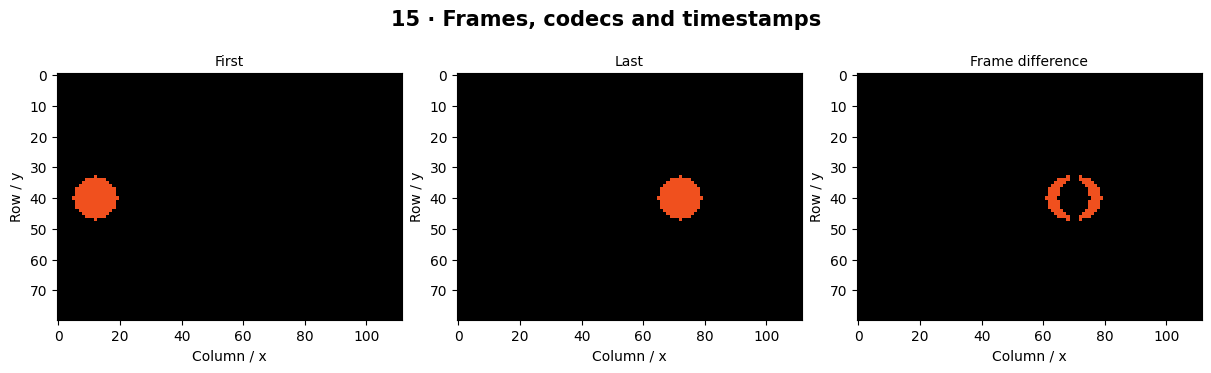

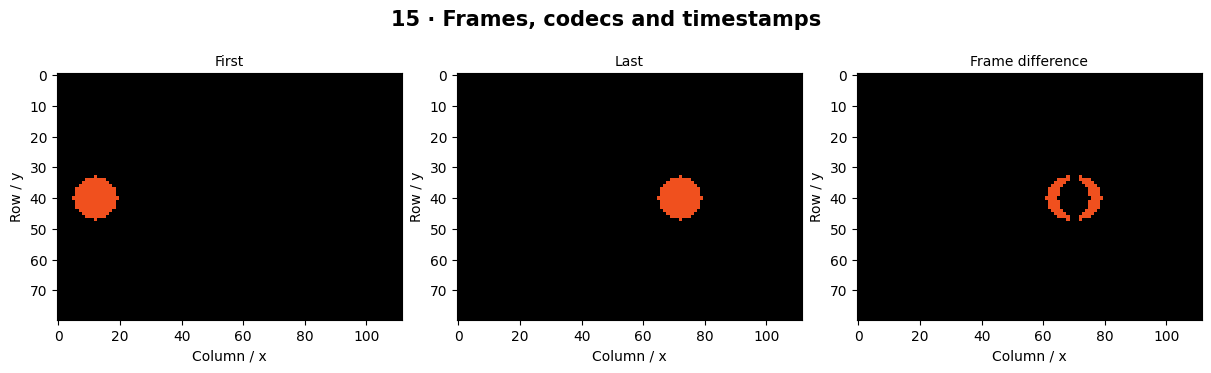

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Motion and Traffic Counter**. Process finite files and release camera resources reliably. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

VideoCapture.read returning false can mean end-of-stream or failure. Writing frames of the wrong shape may silently produce a broken video.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Process every second frame and compare trajectory displacement per processed frame with displacement per second.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a video effects tool with configurable output FPS, verified frame dimensions and a useful error when the source cannot open.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Video containers hold encoded frames and timing metadata; a codec compresses the frames. VideoWriter needs a compatible codec, frame dimensions, color convention and nominal FPS. The lab writes a small generated motion sequence, reads it back and verifies the decoded frame count. Codec availability can differ across operating systems.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Processing loops and timestamps** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/dd/d43/tutorial_py_video_display.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)